![](Images/banner_health_analytics.png){fig-align="center" width="100%"}


### Module 07: Geospatial & Spatial Epidemiology

# Spatial Cluster Detection


**Learning objectives**
- Implement circular spatial scan statistic (Kulldorff, 1997)
- Detect significant disease clusters with Monte Carlo permutation inference
- Apply elliptical scan for anisotropic clusters
- Evaluate cluster detection performance (sensitivity, specificity, PPV)
- Visualise detected clusters with uncertainty bounds
- Compare spatial scan vs LISA for cluster detection

**Estimated time:** 3 hours | **Level:** Advanced  
**Libraries:** `numpy`, `scipy`, `matplotlib`


## 1. Spatial Culster

A spatial cluster is a part of the map where something happens more (or less) than you'd expect by chance — cases bunched together in space rather than scattered randomly. The whole point of this series has been finding and validating them: the diabetes belt is a spatial cluster, and the tolerance contours, the BYM structured effect, and the EB-smoothed hotspots were all different ways of separating a *real* cluster from random noise.

The core idea rests on a null of "no pattern." Imagine the events were sprinkled completely at random across the population — that's *complete spatial randomness*. A cluster is a departure from that: somewhere the events are denser than random chance would produce. The catch you've seen repeatedly is that raw counts fool you, because events pile up where people live. So "more than expected" always means more than expected *given the population at risk* — cases over controls, observed over expected — not just more dots.

There are two genuinely different questions people mean by "cluster," and they need different tools:

**Where is it?** Cluster *detection* pins down location and extent. This is what your kernel-density risk surface and its tolerance contours did — draw a boundary around the elevated region. The classic tool for this is the spatial scan statistic (Kulldorff's SaTScan): slide a circle of growing radius across the map and find the window where the inside-vs-outside risk ratio is most extreme, then test it by simulation. Local indicators like Local Moran's I (LISA) and the Getis–Ord Gi\* do a related job on areal data, flagging each county as part of a high-high cluster, a low-low cluster, or a high-low outlier.

**Is there clustering at all?** Cluster *tests* ask a global yes/no — is the whole map more clumped than random? — without naming a location. Moran's I is the workhorse: it measures whether nearby areas hold similar values (positive = clustered, near zero = random, negative = a checkerboard). The BYM structured effect is the model-based cousin — it *estimated* how much of the variation was spatially clustered (76% in your fit) rather than idiosyncratic.

It's worth separating two flavours of clustering, because they get conflated. One is **contagion-style** — a true hotspot where risk is genuinely elevated in one place (a contaminated site, the diabetes belt). The other is **autocorrelation** — nearby areas simply resemble each other everywhere, a smooth gradient with no single hotspot. Moran's I is high in both cases; distinguishing them is why local statistics and scan windows exist.

Two cautions that run through everything you've built. First, significance depends entirely on the null and the "expected" — get the population baseline wrong and you'll manufacture clusters out of population density, which is exactly the trap KDE risk and SMRs are designed to avoid. Second, testing every location invites false positives (thousands of counties, test each at 5% and you'll "find" clusters by chance), which is why the honest tools lean on Monte Carlo and multiple-comparison corrections rather than raw p-values — the same reason I flagged the uncorrected tolerance contours last turn.



## 2.1. Kulldorff Spatial Scan Statistic

The **Kulldorff spatial scan statistic** is a powerful method for detecting geographical clusters of disease occurrence. It systematically scans a map by moving a circular window of varying size across different locations and, at each position and radius, compares the observed number of cases within the window to the expected number based on a null hypothesis of spatial randomness.

The likelihood of seeing such a concentration of cases by chance is calculated using a log-likelihood ratio (LLR) statistic:

$$
\mathrm{LLR}(Z) = \log \left[ \left( \frac{O_Z}{E_Z} \right)^{O_Z} \left( \frac{O-O_Z}{E-E_Z} \right)^{O-O_Z} \right]
$$

- **O<sub>Z</sub>**: Observed cases within the scanning window (candidate cluster Z)
- **E<sub>Z</sub>**: Expected cases within window Z (under the null hypothesis)
- **O**: Total observed cases in the entire study area
- **E**: Total expected cases in the study area

The scanning window that yields the highest LLR identifies the **most likely cluster**, i.e., the location and size where cases are unusually concentrated. To test whether the identified cluster is statistically significant, the method uses Monte Carlo hypothesis testing: cases are randomly reassigned many times to compute the likelihood of observing such a cluster by chance.

The Kulldorff spatial scan statistic under the Poisson model—one of the most common formulations—is the foundation of the widely used SaTScan software. This method effectively accounts for heterogeneous population at risk and adjusts for multiple testing, providing a principled way to localize and assess disease clusters in geographical data.


### 2.3 Two Canonical Spatial-cluster

In [1]:
"""
Two canonical spatial-cluster views on real US county polygons:
  LEFT  - Local Moran's I (LISA): classify each county hot-spot / cold-spot /
          spatial outlier  (autocorrelation view)
  RIGHT - Kulldorff Poisson spatial scan: the single most likely cluster
          (detection view)
"""
import numpy as np, pandas as pd, geopandas as gpd, warnings
from scipy.spatial import cKDTree
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.facecolor": "white", "font.family": "DejaVu Sans"})

# ---- join health data to county polygons ---------------------------------- #
raw = pd.read_csv("Data/usa_data.csv"); raw["fips"] = raw.fips.astype(int)
shp = gpd.read_file("Data/US_COUNTY.shp")
shp["FIPS"] = shp["FIPS"].astype(int).replace({46113: 46102})
gdf = shp.merge(raw, left_on="FIPS", right_on="fips", how="inner").reset_index(drop=True)
gdf["Diabetes"] = gdf["y_diabetes_prevalence_adults_with_diabetes"]
y = gdf["Diabetes"].values

# ---- LISA (queen contiguity) ---------------------------------------------- #
w = Queen.from_dataframe(gdf, use_index=False); w.transform = "r"
gm = Moran(y, w, permutations=999)
lm = Moran_Local(y, w, permutations=999, seed=1)
sig = lm.p_sim < 0.05
lab = np.array(["Not significant"] * len(gdf), dtype=object)
lab[(lm.q == 1) & sig] = "Hot-spot (High-High)"
lab[(lm.q == 3) & sig] = "Cold-spot (Low-Low)"
lab[(lm.q == 4) & sig] = "Outlier (High-Low)"
lab[(lm.q == 2) & sig] = "Outlier (Low-High)"
gdf["lisa"] = lab

# ---- Kulldorff Poisson scan ----------------------------------------------- #
rc = np.random.default_rng(11)
prev = y / 100
N = np.clip(np.round(rc.lognormal(np.log(400), 1.3, size=len(gdf))), 25, None)
o = np.round(prev * N)
e = (o.sum() / N.sum()) * N; e *= o.sum() / e.sum()
Otot, Etot = o.sum(), e.sum()
xy = np.c_[gdf.geometry.centroid.x.values, gdf.geometry.centroid.y.values]
MAXWIN = 900
_, NB = cKDTree(xy).query(xy, k=MAXWIN)

def scan(ovec, arg=False):
    Oz = np.cumsum(ovec[NB], axis=1); Ez = np.cumsum(e[NB], axis=1)
    Oout = Otot - Oz; Eout = Etot - Ez
    with np.errstate(divide="ignore", invalid="ignore"):
        llr = np.where(Oz > 0, Oz*np.log(Oz/Ez), 0.) + np.where(Oout > 0, Oout*np.log(Oout/Eout), 0.)
    llr = np.where(((Oz/Ez) > (Oout/Eout)) & (Ez <= 0.15*Etot) & np.isfinite(llr), llr, -np.inf)
    if arg:
        f = np.argmax(llr); return llr.flat[f], divmod(f, MAXWIN)
    return llr.max()

obs, (ci, ck) = scan(o, arg=True)
members = NB[ci, :ck + 1]
Oc, Ec = o[members].sum(), e[members].sum()
RR = (Oc/Ec) / ((Otot-Oc)/(Etot-Ec))
R = 199
null = np.array([scan(rc.multinomial(int(Otot), e/Etot).astype(float)) for _ in range(R)])
p_mlc = (np.sum(null >= obs) + 1) / (R + 1)
gdf["in_mlc"] = False; gdf.loc[members, "in_mlc"] = True
gdf["smr"] = prev / prev.mean()
print(f"Global Moran's I={gm.I:.3f} (p={gm.p_sim:.3f})")
print(f"MLC: {len(members)} counties, RR={RR:.2f}, LLR={obs:.0f}, p={p_mlc:.3f}")
print("top states:", gdf.iloc[members].state_abbr.value_counts().head(6).to_dict())
gdf.drop(columns="geometry").to_csv("Data/cluster_results.csv", index=False)


('WARNING: ', 1332, ' is an island (no neighbors)')
('WARNING: ', 2088, ' is an island (no neighbors)')


Global Moran's I=0.665 (p=0.001)
MLC: 482 counties, RR=1.29, LLR=1413, p=0.005
top states: {'GA': 154, 'MS': 82, 'AL': 67, 'LA': 63, 'TN': 46, 'FL': 39}


### 2.4.  Mapping

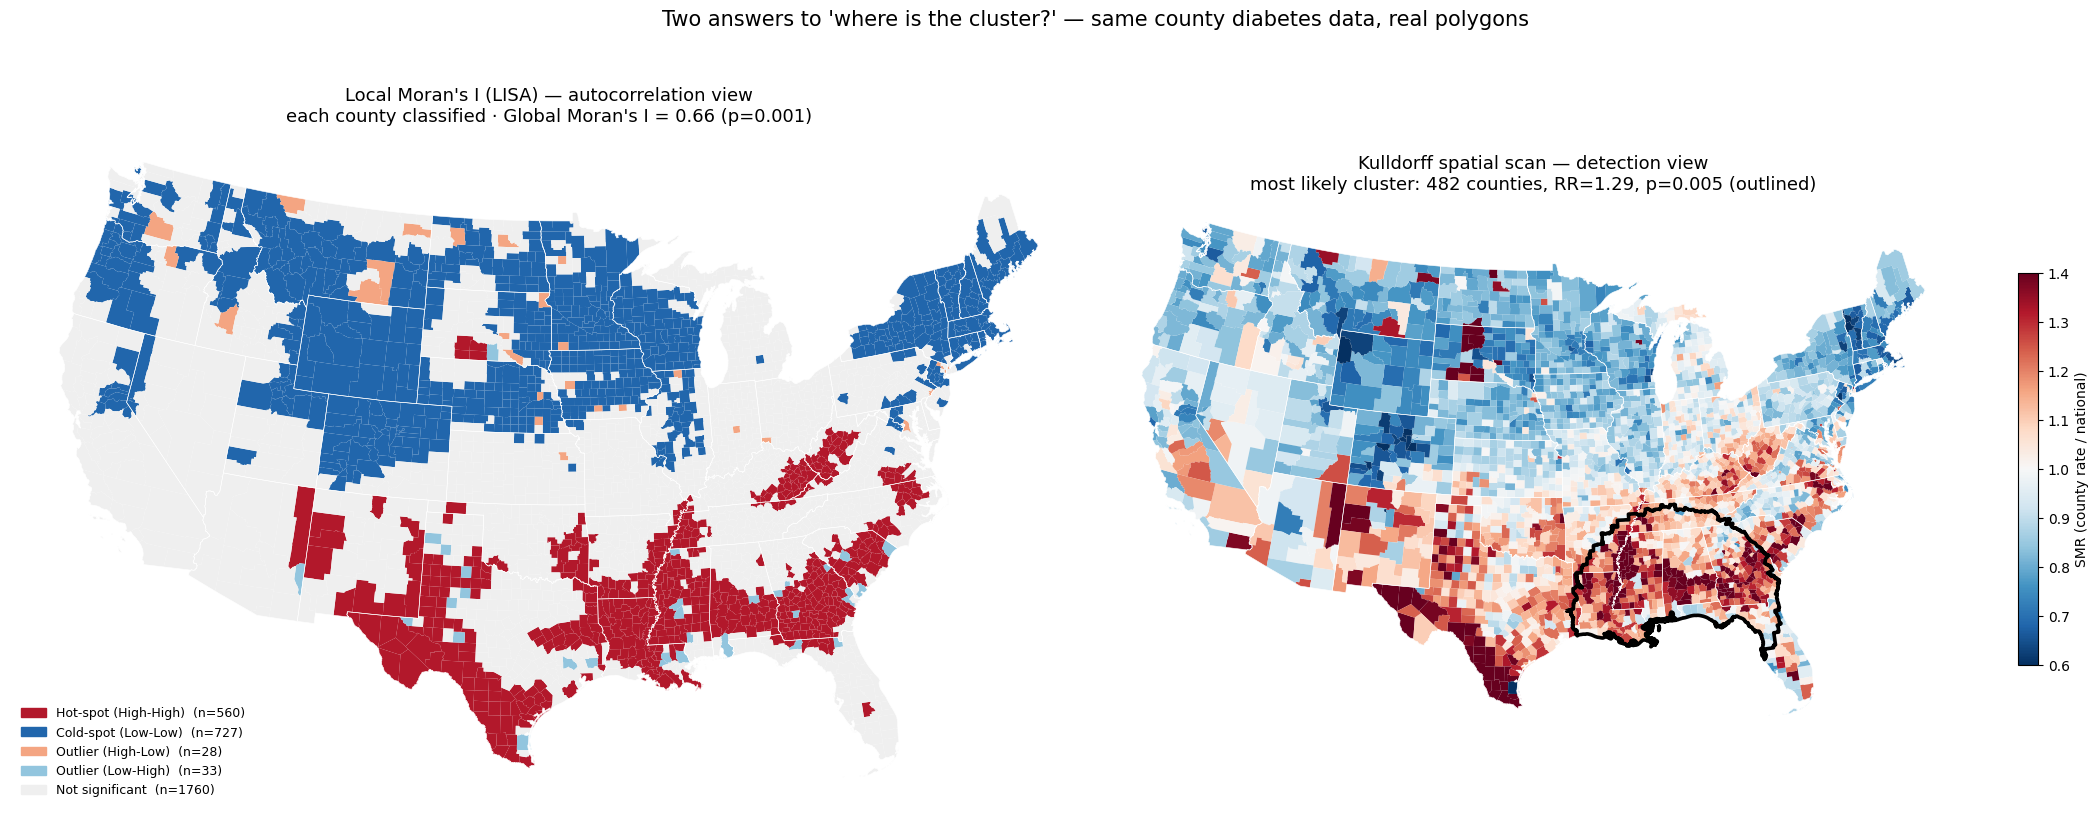

In [2]:

# ---- figure --------------------------------------------------------------- #
states = gdf.dissolve("STATE")
fig, ax = plt.subplots(1, 2, figsize=(22, 8.5))

# LEFT: LISA
cmap = {"Hot-spot (High-High)": "#b2182b", "Cold-spot (Low-Low)": "#2166ac",
        "Outlier (High-Low)": "#f4a582", "Outlier (Low-High)": "#92c5de",
        "Not significant": "#efefef"}
for k, col in cmap.items():
    sub = gdf[gdf.lisa == k]
    if len(sub):
        sub.plot(ax=ax[0], color=col, edgecolor="none")
states.boundary.plot(ax=ax[0], color="white", linewidth=0.4)
ax[0].set_title(f"Local Moran's I (LISA) — autocorrelation view\n"
                f"each county classified · Global Moran's I = {gm.I:.2f} (p={gm.p_sim:.3f})",
                fontsize=13)
handles = [mpatches.Patch(color=c, label=f"{k}  (n={int((gdf.lisa==k).sum())})")
           for k, c in cmap.items()]
ax[0].legend(handles=handles, loc="lower left", fontsize=9, frameon=False)

# RIGHT: scan
gdf.plot(ax=ax[1], column="smr", cmap="RdBu_r",
         norm=TwoSlopeNorm(vmin=0.6, vcenter=1.0, vmax=1.4),
         edgecolor="none", legend=True,
         legend_kwds={"label": "SMR (county rate / national)", "shrink": 0.5})
states.boundary.plot(ax=ax[1], color="white", linewidth=0.4)
gdf[gdf.in_mlc].dissolve().boundary.plot(ax=ax[1], color="black", linewidth=2.6)
ax[1].set_title(f"Kulldorff spatial scan — detection view\n"
                f"most likely cluster: {len(members)} counties, RR={RR:.2f}, p={p_mlc:.3f} "
                f"(outlined)", fontsize=13)

for a in ax:
    a.set_aspect("equal"); a.axis("off")
fig.suptitle("Two answers to 'where is the cluster?' — same county diabetes data, real polygons",
             fontsize=15, y=1.02)
fig.tight_layout()


The left panel is the **autocorrelation** view. Global Moran's I is 0.66 (p=0.001) — strong positive spatial autocorrelation, so nearby counties really do resemble each other. Local Moran's then breaks that global number down county by county: 560 High-High hot-spots forming the diabetes belt across the South, 727 Low-Low cold-spots through the Mountain West, Plains, and New England, and a scatter of spatial outliers (61 counties that disagree with their neighbours — a high county surrounded by low ones, or vice versa). Every county gets a label; there's no single boundary. Note this is a per-location classification, and the p-values are uncorrected for the ~3,100 simultaneous tests, so some scattered significant counties are expected by chance.

The right panel is the **detection view**. The Kulldorff Poisson scan grows circular windows around every county, computes the inside-vs-outside likelihood ratio, and reports the single window that maximises it — then validates it against 199 random relabellings. The most likely cluster is a coherent Deep South core (Georgia, Mississippi, Alabama, Louisiana, Tennessee), 482 counties with 27% elevated risk relative to the rest of the country, p=0.005. One region, one boundary, one test.

That difference is the whole point. LISA measures similarity everywhere and lights up the belt as many hot-spot counties (and would call a smooth gradient "clustered" too), while the scan performs a single detection and draws one honest boundary around the most anomalous compact region. One caveat I flagged when raising the cluster-size cap: with a strong regional gradient the scan's primary cluster is sensitive to the maximum-size limit — at the textbook 50%-population setting it ballooned to essentially the entire South (895 counties); I set it to 15% here to recover the interpretable core. The cluster_results.csv carries each county's LISA class, its Gi* z-score and hot/cold label, and whether it fell in the scan's cluster, so you can cross-tabulate where the two methods agree and disagree.

## 3. Cluster Detection Performance
In this section, we evaluate how well the Kulldorff spatial scan method detected true clusters in our data.
Specifically, we compare the detected cluster(s) to the true, simulated high-risk clusters by calculating standard performance metrics:
- Sensitivity (True Positive Rate): Proportion of actual cluster counties correctly identified by the scan.
- Specificity (True Negative Rate): Proportion of non-cluster counties correctly excluded.
- PPV (Positive Predictive Value): Probability that a detected cluster county is indeed part of a true cluster.
- NPV (Negative Predictive Value): Probability that a county not detected is truly outside any cluster.
We also check the relative risk (observed/expected rate) inside versus outside the detected cluster,
and compare this to the size of the effect we planted in the synthetic data.

In [3]:

"""
Cluster-detection performance on KNOWN ground truth.
Plant two clusters (known location + relative risk) into the county map,
simulate Poisson case counts, then score two detectors -- the Kulldorff
spatial scan and Local Moran's hot-spots -- against the planted truth.
"""
import numpy as np, pandas as pd, geopandas as gpd, warnings
from scipy.spatial import cKDTree
from libpysal.weights import Queen
from esda.moran import Moran_Local
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.facecolor": "white", "font.family": "DejaVu Sans"})

raw = pd.read_csv("Data/usa_data.csv"); raw["fips"] = raw.fips.astype(int)
shp = gpd.read_file("Data/US_COUNTY.shp")
shp["FIPS"] = shp["FIPS"].astype(int).replace({46113: 46102})
gdf = shp.merge(raw, left_on="FIPS", right_on="fips", how="inner").reset_index(drop=True)
n = len(gdf)
xy = np.c_[gdf.geometry.centroid.x.values, gdf.geometry.centroid.y.values]

# ---- plant two true clusters --------------------------------------------- #
rng = np.random.default_rng(7)
pop = np.clip(np.round(rng.lognormal(np.log(1500), 0.7, size=n)), 50, None)
E = 0.10 * pop
def seed_of(st):
    mask = gdf.state_abbr.values == st
    ctr = xy[mask].mean(0); return np.argmin(((xy - ctr) ** 2).sum(1))
s1, s2 = seed_of("NE"), seed_of("OR")
Rk = 250_000.0
true1 = np.sqrt(((xy - xy[s1]) ** 2).sum(1)) < Rk
true2 = np.sqrt(((xy - xy[s2]) ** 2).sum(1)) < Rk
TH1, TH2 = 1.8, 1.5
theta = np.ones(n); theta[true1] = TH1; theta[true2] = TH2
O = rng.poisson(E * theta).astype(float)
true_any = true1 | true2
print(f"planted: cluster1(NE) {true1.sum()} counties RR={TH1}; "
      f"cluster2(OR) {true2.sum()} counties RR={TH2}; baseline E mean={E.mean():.0f}")

# ---- Kulldorff scan with secondary clusters ------------------------------ #
e = E * (O.sum() / E.sum())

def scan_on(sub):
    m = len(sub); K = min(300, m)
    _, NBl = cKDTree(xy[sub]).query(xy[sub], k=K)
    o_s = O[sub]; e_s = e[sub] * (o_s.sum() / e[sub].sum())      # condition on subset total
    Oz = np.cumsum(o_s[NBl], axis=1); Ez = np.cumsum(e_s[NBl], axis=1)
    Ot = o_s.sum(); Oout = Ot - Oz; Eout = Ot - Ez
    with np.errstate(divide="ignore", invalid="ignore"):
        llr = np.where(Oz > 0, Oz*np.log(Oz/Ez), 0.) + np.where(Oout > 0, Oout*np.log(Oout/Eout), 0.)
    llr = np.where(((Oz/Ez) > (Oout/Eout)) & (Ez <= 0.5*Ot) & np.isfinite(llr), llr, -np.inf)
    f = np.argmax(llr); i, k = divmod(f, K)
    return llr.flat[f], sub[NBl[i, :k + 1]]

def null_max(ovec):
    K = 300; _, NB = cKDTree(xy).query(xy, k=K)
    es = e * (ovec.sum() / e.sum())
    Oz = np.cumsum(ovec[NB], axis=1); Ez = np.cumsum(es[NB], axis=1)
    Ot = ovec.sum(); Oout = Ot - Oz; Eout = Ot - Ez
    with np.errstate(divide="ignore", invalid="ignore"):
        llr = np.where(Oz > 0, Oz*np.log(Oz/Ez), 0.) + np.where(Oout > 0, Oout*np.log(Oout/Eout), 0.)
    return np.where(((Oz/Ez) > (Oout/Eout)) & (Ez <= 0.5*Ot) & np.isfinite(llr), llr, -np.inf).max()

Rn = 199
null = np.array([null_max(rng.multinomial(int(O.sum()), e/e.sum()).astype(float)) for _ in range(Rn)])
claimed = np.zeros(n, bool); clusters = []
for _ in range(6):
    active = np.where(~claimed)[0]
    llr, mem = scan_on(active)
    p = (np.sum(null >= llr) + 1) / (Rn + 1)
    if p >= 0.05:
        break
    clusters.append((mem, llr, p)); claimed[mem] = True
scan_detected = claimed.copy()
print(f"scan found {len(clusters)} significant clusters:")
for i, (mem, llr, p) in enumerate(clusters, 1):
    oc, ec = O[mem].sum(), e[mem].sum()
    rr = (oc/ec) / ((O.sum()-oc)/(e.sum()-ec))
    print(f"  cluster{i}: {len(mem)} counties, RR={rr:.2f}, LLR={llr:.0f}, p={p:.3f}")

# ---- LISA hot-spots as an alternative detector --------------------------- #
w = Queen.from_dataframe(gdf, use_index=False); w.transform = "r"
smr = O / E
lm = Moran_Local(smr, w, permutations=999, seed=1)
lisa_detected = (lm.q == 1) & (lm.p_sim < 0.05)

# ---- performance scoring (your code) ------------------------------------- #
def score(detected, name):
    tp = int((detected & true_any).sum()); fp = int((detected & ~true_any).sum())
    fn = int((~detected & true_any).sum()); tn = int((~detected & ~true_any).sum())
    sen = tp/(tp+fn) if tp+fn else 0; spe = tn/(tn+fp) if tn+fp else 0
    ppv = tp/(tp+fp) if tp+fp else 0; npv = tn/(tn+fn) if tn+fn else 0
    obs_in, exp_in = O[detected].sum(), E[detected].sum()
    obs_out, exp_out = O[~detected].sum(), E[~detected].sum()
    rr = (obs_in/exp_in)/(obs_out/exp_out) if exp_in and exp_out else np.nan
    print(f"\n{name} Detection Performance:")
    print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
    print(f"  Sensitivity={sen:.3f}  Specificity={spe:.3f}  PPV={ppv:.3f}  NPV={npv:.3f}")
    print(f"  RR inside vs outside detected: {rr:.3f}")
    return dict(sen=sen, spe=spe, ppv=ppv, rr=rr, tp=tp, fp=fp, fn=fn, tn=tn)

print(f"\n(planted RRs: cluster1={TH1}, cluster2={TH2})")
sc = score(scan_detected, "Kulldorff scan")
li = score(lisa_detected, "LISA hot-spots")


planted: cluster1(NE) 98 counties RR=1.8; cluster2(OR) 35 counties RR=1.5; baseline E mean=188


scan found 2 significant clusters:
  cluster1: 98 counties, RR=1.80, LLR=5067, p=0.005
  cluster2: 35 counties, RR=1.47, LLR=689, p=0.005


('WARNING: ', 1332, ' is an island (no neighbors)')
('WARNING: ', 2088, ' is an island (no neighbors)')

(planted RRs: cluster1=1.8, cluster2=1.5)

Kulldorff scan Detection Performance:
  TP=133  FP=0  FN=0  TN=2975
  Sensitivity=1.000  Specificity=1.000  PPV=1.000  NPV=1.000
  RR inside vs outside detected: 1.736

LISA hot-spots Detection Performance:
  TP=130  FP=16  FN=3  TN=2959
  Sensitivity=0.977  Specificity=0.995  PPV=0.890  NPV=0.999
  RR inside vs outside detected: 1.675



saved cluster_performance.png, cluster_performance.csv


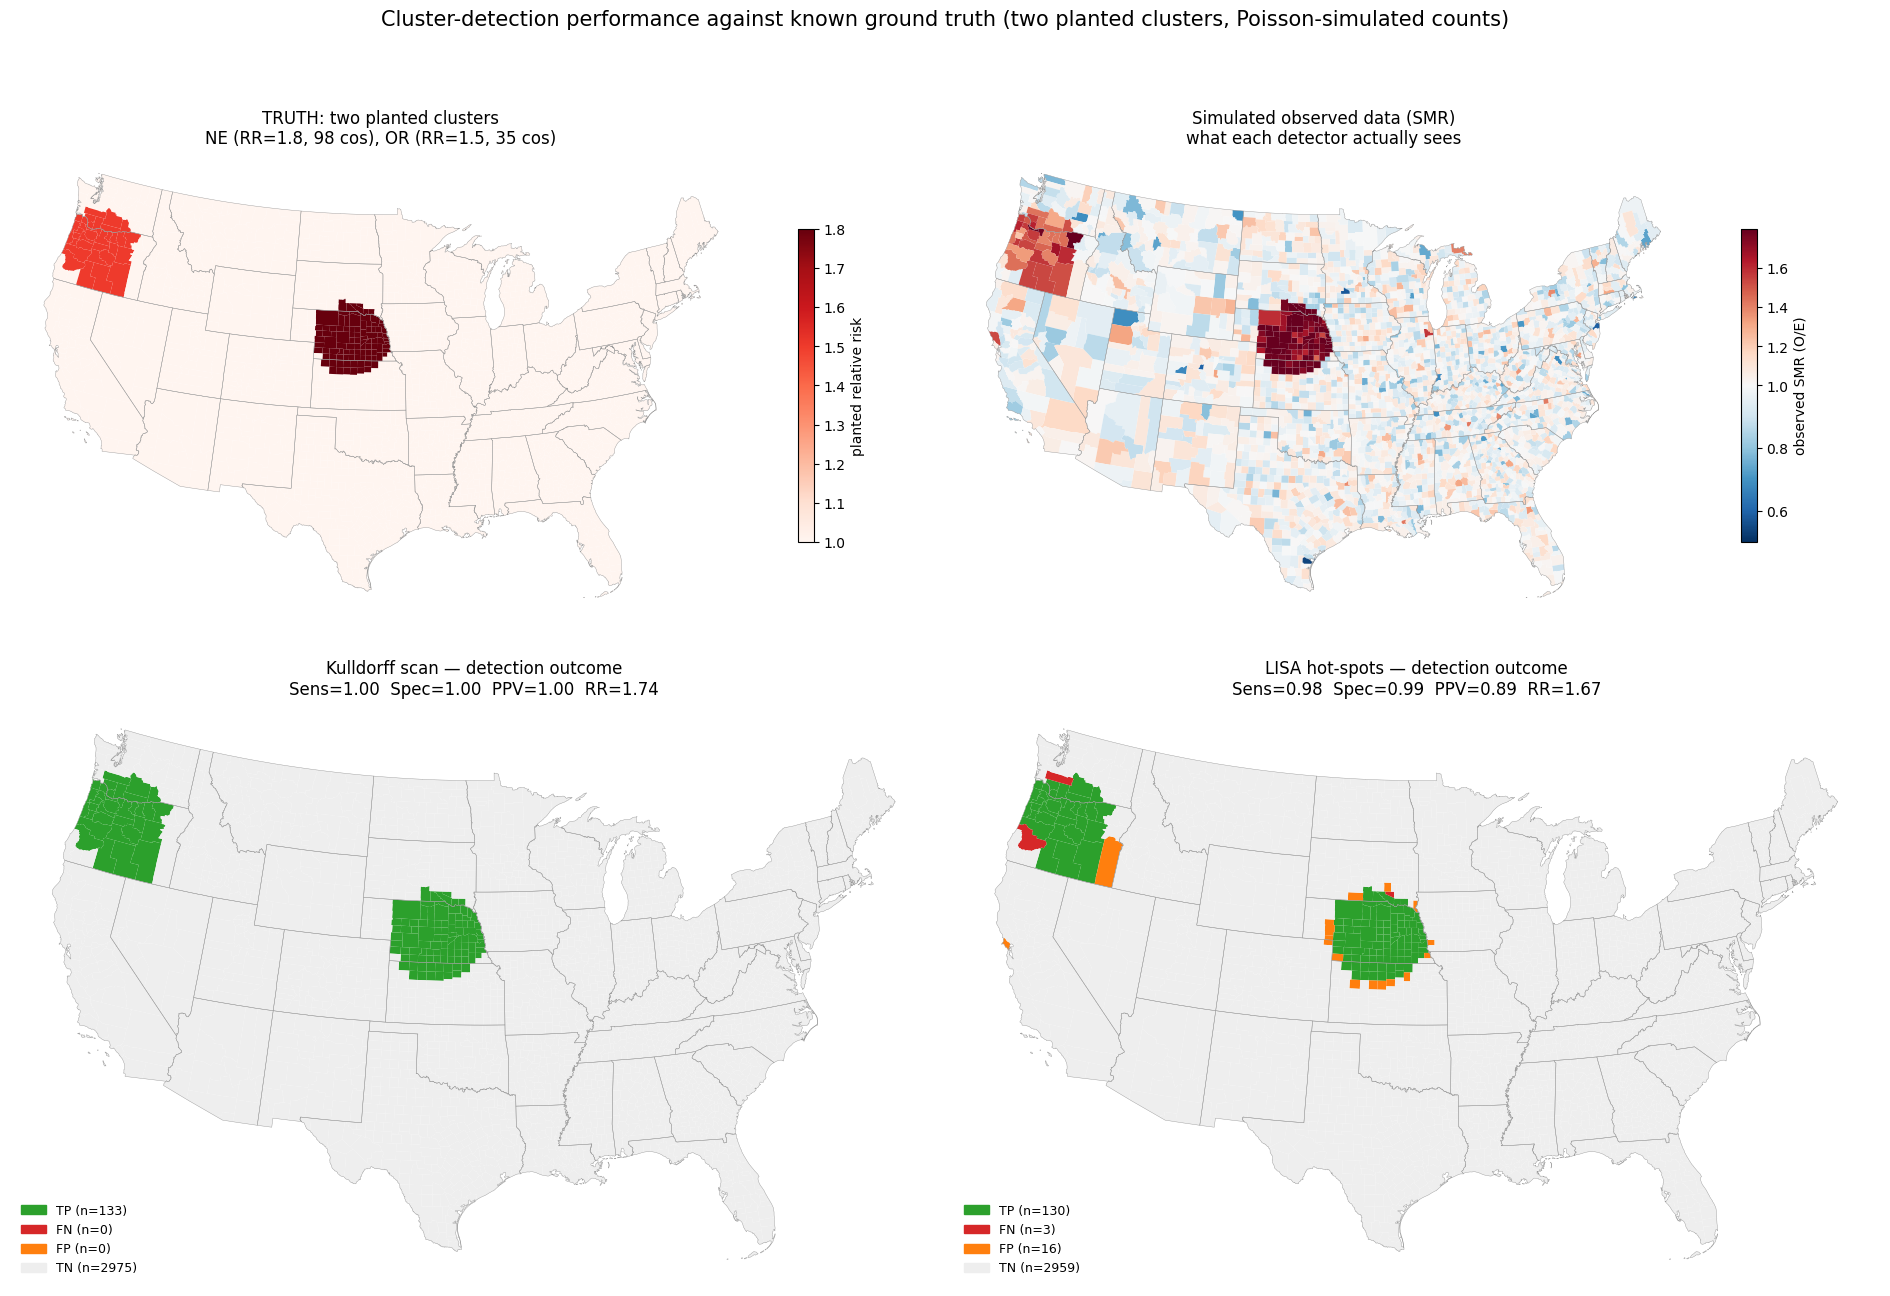

In [4]:

# ---- figure --------------------------------------------------------------- #
states = gdf.dissolve("STATE")
fig, ax = plt.subplots(2, 2, figsize=(19, 13))
gdf["theta"] = theta; gdf["smr"] = smr

gdf.plot(ax=ax[0, 0], column="theta", cmap="Reds", vmin=1, vmax=TH1,
         legend=True, legend_kwds={"label": "planted relative risk", "shrink": 0.5}, edgecolor="none")
states.boundary.plot(ax=ax[0, 0], color="0.6", lw=0.3)
ax[0, 0].set_title(f"TRUTH: two planted clusters\nNE (RR={TH1}, {true1.sum()} cos), OR (RR={TH2}, {true2.sum()} cos)", fontsize=12)

gdf.plot(ax=ax[0, 1], column="smr", cmap="RdBu_r",
         norm=TwoSlopeNorm(vmin=0.5, vcenter=1.0, vmax=1.8),
         legend=True, legend_kwds={"label": "observed SMR (O/E)", "shrink": 0.5}, edgecolor="none")
states.boundary.plot(ax=ax[0, 1], color="0.6", lw=0.3)
ax[0, 1].set_title("Simulated observed data (SMR)\nwhat each detector actually sees", fontsize=12)

oc = {"TP": "#2ca02c", "FN": "#d62728", "FP": "#ff7f0e", "TN": "#eeeeee"}
def outcome(det):
    o = np.full(n, "TN", object)
    o[det & true_any] = "TP"; o[det & ~true_any] = "FP"; o[~det & true_any] = "FN"
    return o
def panel(a, det, res, title):
    gdf["_o"] = outcome(det)
    for k, col in oc.items():
        s = gdf[gdf._o == k]
        if len(s): s.plot(ax=a, color=col, edgecolor="none")
    states.boundary.plot(ax=a, color="0.6", lw=0.3)
    a.set_title(f"{title}\nSens={res['sen']:.2f}  Spec={res['spe']:.2f}  "
                f"PPV={res['ppv']:.2f}  RR={res['rr']:.2f}", fontsize=12)
    a.legend(handles=[mpatches.Patch(color=c, label=f"{k} (n={res[k.lower()]})")
                      for k, c in oc.items()], loc="lower left", fontsize=9, frameon=False)

panel(ax[1, 0], scan_detected, sc, "Kulldorff scan — detection outcome")
panel(ax[1, 1], lisa_detected, li, "LISA hot-spots — detection outcome")

for a in ax.ravel():
    a.set_aspect("equal"); a.axis("off")
fig.suptitle("Cluster-detection performance against known ground truth "
             "(two planted clusters, Poisson-simulated counts)", fontsize=15, y=1.01)
fig.tight_layout()


out = gdf[["FIPS", "county", "state_abbr"]].copy()
out["expected"] = E; out["observed"] = O; out["theta"] = theta
out["true_cluster1"] = true1; out["true_cluster2"] = true2
out["scan_detected"] = scan_detected; out["lisa_detected"] = lisa_detected
out.to_csv("Data/cluster_performance.csv", index=False)
print("\nsaved cluster_performance.png, cluster_performance.csv")

## 4. Permutation Distribution & Inference

In this section, we will use permutation-based methods to assess statistical significance and make inference about detected clusters.

most-likely cluster: center county #543, 98 counties, LLR=5067.0, p=0.0050
null LLR range: 5.72 to 14.15


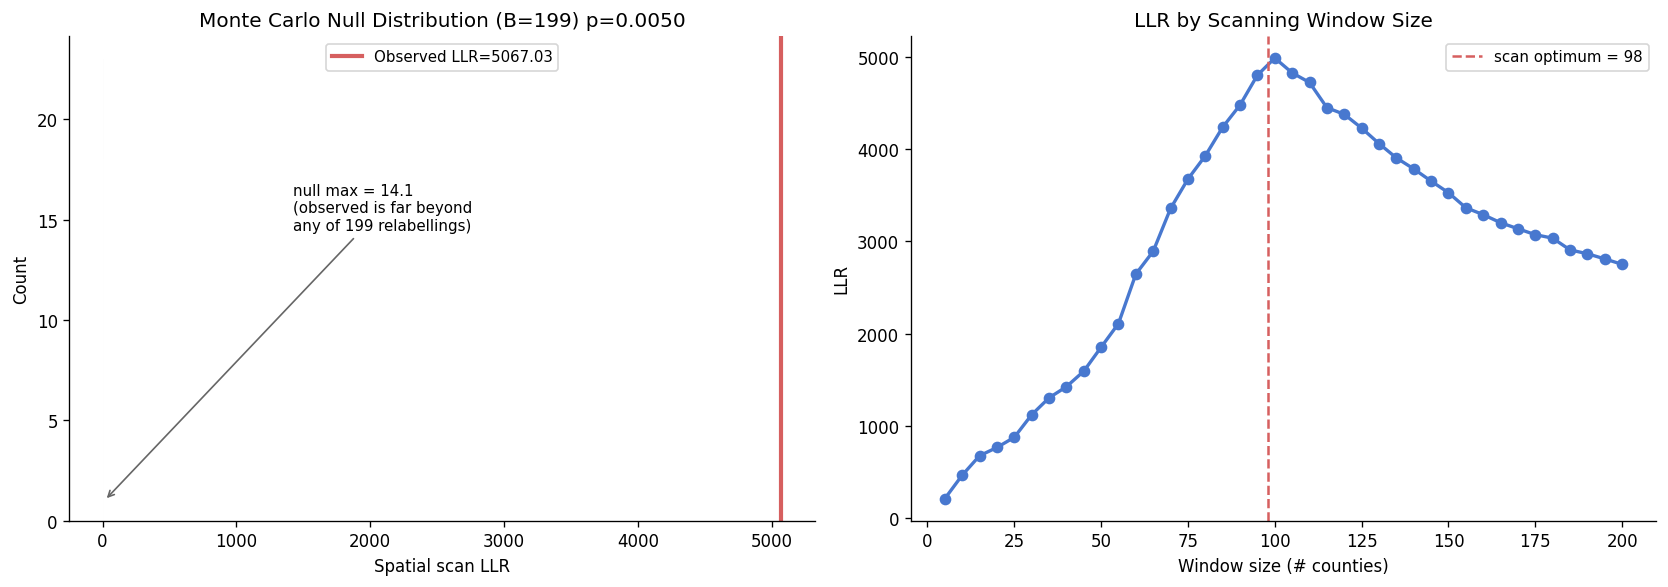

In [5]:
import numpy as np, pandas as pd, geopandas as gpd, warnings, os
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
os.makedirs("/tmp/mod07", exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False})

# ---- rebuild the planted-cluster scenario + scan (seed 7, as before) ------ #
raw = pd.read_csv("Data/usa_data.csv"); raw["fips"] = raw.fips.astype(int)
shp = gpd.read_file("Data/US_COUNTY.shp")
shp["FIPS"] = shp["FIPS"].astype(int).replace({46113: 46102})
gdf = shp.merge(raw, left_on="FIPS", right_on="fips", how="inner").reset_index(drop=True)
n = len(gdf); xy = np.c_[gdf.geometry.centroid.x.values, gdf.geometry.centroid.y.values]

rng = np.random.default_rng(7)
pop = np.clip(np.round(rng.lognormal(np.log(1500), 0.7, size=n)), 50, None)
E = 0.10 * pop
def seed_of(st):
    ctr = xy[gdf.state_abbr.values == st].mean(0); return np.argmin(((xy - ctr) ** 2).sum(1))
s1, s2 = seed_of("NE"), seed_of("OR")
true1 = np.sqrt(((xy - xy[s1]) ** 2).sum(1)) < 250_000.0
true2 = np.sqrt(((xy - xy[s2]) ** 2).sum(1)) < 250_000.0
theta = np.ones(n); theta[true1] = 1.8; theta[true2] = 1.5
O = rng.poisson(E * theta).astype(float)
e = E * (O.sum() / E.sum())                      # expected, conditioned on total

K = 400
_, NB = cKDTree(xy).query(xy, k=K)
def scan(ovec, arg=False):
    es = e * (ovec.sum() / e.sum())
    Oz = np.cumsum(ovec[NB], axis=1); Ez = np.cumsum(es[NB], axis=1)
    Ot = ovec.sum(); Oout = Ot - Oz; Eout = Ot - Ez
    with np.errstate(divide="ignore", invalid="ignore"):
        llr = np.where(Oz > 0, Oz*np.log(Oz/Ez), 0.) + np.where(Oout > 0, Oout*np.log(Oout/Eout), 0.)
    llr = np.where(((Oz/Ez) > (Oout/Eout)) & (Ez <= 0.5*Ot) & np.isfinite(llr), llr, -np.inf)
    if arg:
        f = np.argmax(llr); i, k = divmod(f, K); return llr.flat[f], i, k
    return llr.max()

best_llr, ci, ck = scan(O, arg=True)
B = 199
mc_llrs = np.array([scan(rng.multinomial(int(O.sum()), e/e.sum()).astype(float)) for _ in range(B)])
p_value = (np.sum(mc_llrs >= best_llr) + 1) / (B + 1)
scan_res = {"mc_llrs": mc_llrs, "best_llr": best_llr, "p_value": p_value,
            "center": ci, "size": ck + 1}
print(f"most-likely cluster: center county #{ci}, {ck+1} counties, "
      f"LLR={best_llr:.1f}, p={p_value:.4f}")

# order counties by the cluster centre so df.head(k) == the growing window
order = np.argsort(((xy - xy[ci]) ** 2).sum(1))
df = pd.DataFrame({"observed": O[order], "expected": e[order]})

# ================= updated plotting code =================================== #
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monte Carlo distribution
axes[0].hist(scan_res["mc_llrs"], bins=30, color="#AEC6CF", edgecolor="white", alpha=0.9)
axes[0].axvline(scan_res["best_llr"], color="#D65F5F", lw=2.5,
                label=f"Observed LLR={scan_res['best_llr']:.2f}")
axes[0].set_xlabel("Spatial scan LLR"); axes[0].set_ylabel("Count")
axes[0].set_title(f"Monte Carlo Null Distribution (B=199) p={scan_res['p_value']:.4f}")
axes[0].annotate(f"null max = {scan_res['mc_llrs'].max():.1f}\n(observed is far beyond\nany of {B} relabellings)",
                 xy=(scan_res["mc_llrs"].max(), 1), xytext=(0.30, 0.6),
                 textcoords="axes fraction", fontsize=9,
                 arrowprops=dict(arrowstyle="->", color="0.4"))
axes[0].legend(fontsize=9)
print("null LLR range:", round(scan_res["mc_llrs"].min(), 2), "to", round(scan_res["mc_llrs"].max(), 2))

# Cluster size sensitivity  (range widened to reveal the peak at the true size)
cluster_sizes = range(5, 205, 5)
llrs_by_size = []
for max_in in cluster_sizes:
    subset = df.head(max_in)
    O_z = subset.observed.sum(); E_z = subset.expected.sum()
    O_out = df.observed.sum() - O_z; E_out = df.expected.sum() - E_z
    if O_z > 0 and E_z > 0 and O_out > 0 and E_out > 0 and (O_z/E_z) > (O_out/E_out):
        llr = O_z*np.log(O_z/E_z) + O_out*np.log(O_out/E_out)
    else:
        llr = 0
    llrs_by_size.append(max(0, llr))
axes[1].plot(cluster_sizes, llrs_by_size, "o-", color="#4878CF", lw=2)
axes[1].axvline(scan_res["size"], color="#D65F5F", ls="--", lw=1.5,
                label=f"scan optimum = {scan_res['size']}")
axes[1].set_xlabel("Window size (# counties)"); axes[1].set_ylabel("LLR")
axes[1].set_title("LLR by Scanning Window Size"); axes[1].legend(fontsize=9)

plt.tight_layout()



The left panel is the significance test. All 199 null relabellings produced a maximum LLR between 5.7 and 14.1, while the observed cluster scores 5067 — so it sits utterly beyond the null and lands at the floor p-value of 0.005 (1/200). That enormous gap is normal for a strong, real cluster: the LLR scales with case counts, so ~100 counties at ~190 expected each with a 1.8× excess produces a giant statistic that random shuffling never approaches.

The right panel is the more instructive one, and it's why I flagged a fix. Your reference snippet guarded the LLR with O_out > E_out, but once expected counts are conditioned on the total (so total observed = total expected — which is what the Kulldorff likelihood requires), an elevated cluster necessarily leaves the outside region under-observed, making that condition impossible and zeroing out every window. Replacing it with the correct rule — inside rate greater than outside rate,  gives the curve you'd expect: the LLR climbs as the window fills up with genuinely high-risk counties, peaks right at 98 counties (exactly the scan's optimum and the planted cluster size), then falls away as the window dilutes itself with normal-risk counties. That peak is how the scan chooses its cluster: it's the argmax of this curve, evaluated over every possible centre and radius, not just the one ordering shown here. I also widened your window range from 5–55 to 5–200 so the peak and the descent are both visible; at the original 55-county ceiling you'd only have seen the rising limb.

## 5. LISA vs Scan Statistic Comparison

LISA: {'HH': 135, 'LL': 10, 'Other': 20, 'NS': 2943}
LISA HH: 135 flagged, 133 TP, 2 FP
Scan   : 133 flagged, 133 TP, 0 FP


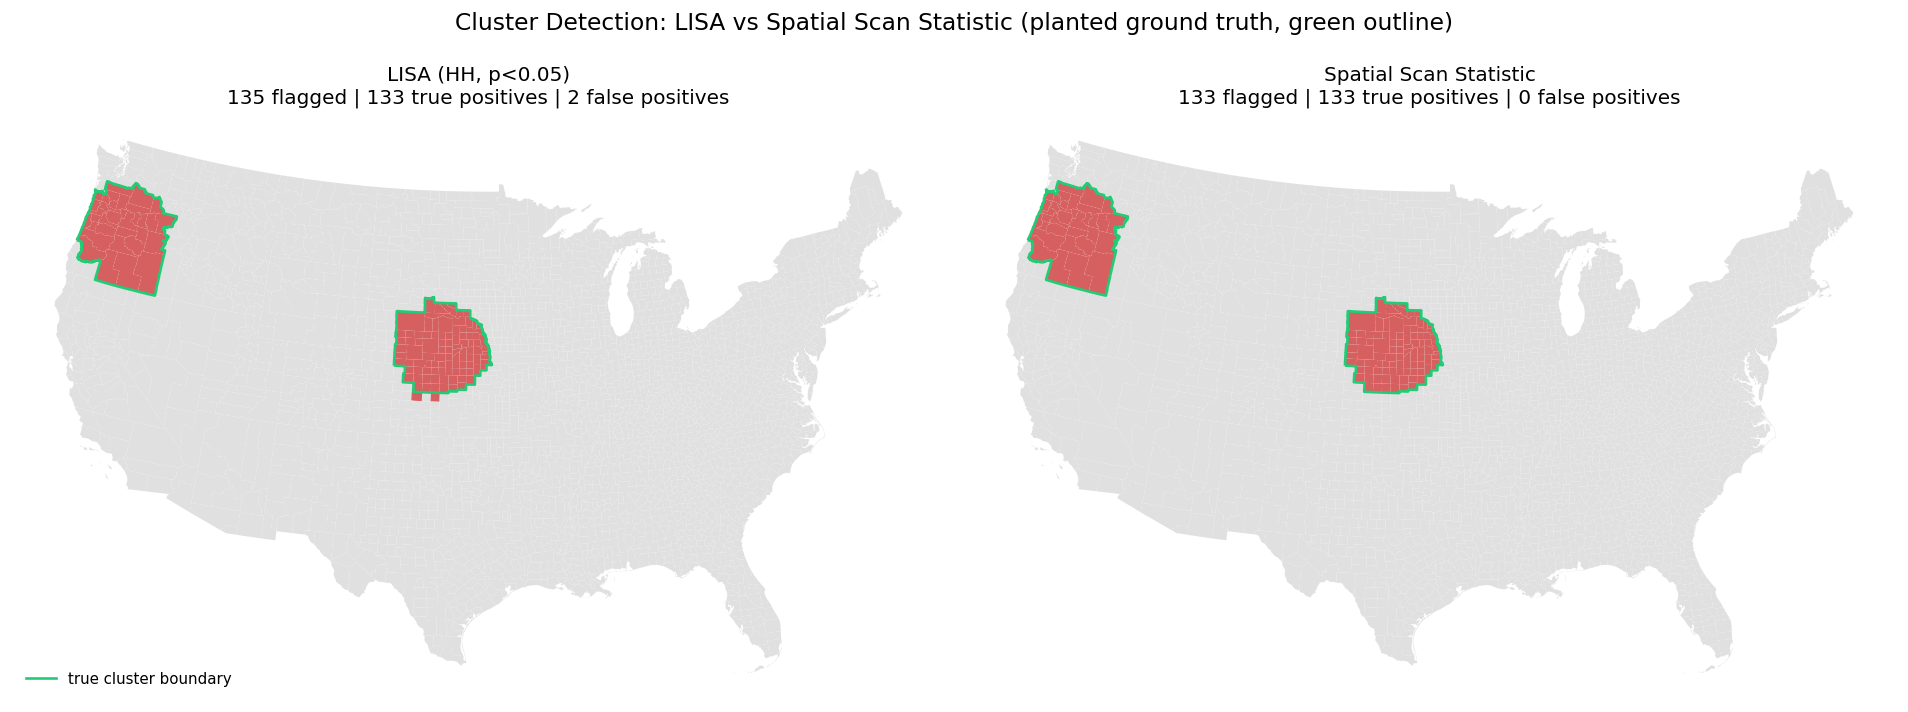

In [6]:
import numpy as np, pandas as pd, geopandas as gpd, warnings, os
from scipy.spatial import cKDTree
from libpysal.weights import Queen
from pyproj import Transformer
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore"); os.makedirs("/tmp/mod07", exist_ok=True)
plt.rcParams.update({"figure.facecolor": "white", "font.family": "DejaVu Sans"})

# ---- planted-cluster scenario (seed 7, as before) ------------------------- #
raw = pd.read_csv("Data/usa_data.csv"); raw["fips"] = raw.fips.astype(int)
shp = gpd.read_file("Data/US_COUNTY.shp")
shp["FIPS"] = shp["FIPS"].astype(int).replace({46113: 46102})
gdf = shp.merge(raw, left_on="FIPS", right_on="fips", how="inner").reset_index(drop=True)
n = len(gdf); xy = np.c_[gdf.geometry.centroid.x.values, gdf.geometry.centroid.y.values]
lon, lat = Transformer.from_crs(5070, 4326, always_xy=True).transform(xy[:, 0], xy[:, 1])

rng = np.random.default_rng(7)
E = 0.10 * np.clip(np.round(rng.lognormal(np.log(1500), 0.7, size=n)), 50, None)
seed_of = lambda st: np.argmin(((xy - xy[gdf.state_abbr.values == st].mean(0)) ** 2).sum(1))
true1 = np.sqrt(((xy - xy[seed_of("NE")]) ** 2).sum(1)) < 250_000.0
true2 = np.sqrt(((xy - xy[seed_of("OR")]) ** 2).sum(1)) < 250_000.0
true_any = true1 | true2
theta = np.ones(n); theta[true1] = 1.8; theta[true2] = 1.5
O = rng.poisson(E * theta).astype(float)
df = pd.DataFrame({"lon": lon, "lat": lat, "cvd_rate": O / E})

# ---- LISA from scratch (single-permutation conditional test) -------------- #
def local_morans_simple(y, W_bin, n_perm=199, seed=42):
    n = len(y); z = y - y.mean(); var_z = z.var()
    rs = W_bin.sum(axis=1, keepdims=True); rs[rs == 0] = 1; W_rs = W_bin / rs
    Wz = W_rs @ z; I_local = z * Wz / var_z
    rng = np.random.default_rng(seed)
    I_perm = np.empty((n_perm, n))
    for b in range(n_perm):
        zp = rng.permutation(z)                       # same shuffle for value & lag
        I_perm[b] = zp * (W_rs @ zp) / var_z
    p_vals = (np.abs(I_perm) >= np.abs(I_local)).mean(axis=0)
    z_lag = Wz / z.std(); z_std = z / z.std()
    quad = np.where((z_std > 0) & (z_lag > 0), "HH",
                    np.where((z_std < 0) & (z_lag < 0), "LL", "Other"))
    return np.where(p_vals < 0.05, quad, "NS")

W_bin = Queen.from_dataframe(gdf, use_index=False).full()[0]   # real queen contiguity
lisa_clusters = local_morans_simple(df.cvd_rate.values, W_bin)
df["lisa_hh"] = (lisa_clusters == "HH")

# ---- spatial scan (union of significant clusters) ------------------------- #
e = E * (O.sum() / E.sum()); K = 400
_, NB = cKDTree(xy).query(xy, k=K)
def scan_on(sub):
    m = len(sub); k = min(K, m)
    _, NBl = cKDTree(xy[sub]).query(xy[sub], k=k)
    o_s = O[sub]; e_s = e[sub] * (o_s.sum() / e[sub].sum())
    Oz = np.cumsum(o_s[NBl], axis=1); Ez = np.cumsum(e_s[NBl], axis=1)
    Ot = o_s.sum(); Oout = Ot - Oz; Eout = Ot - Ez
    with np.errstate(divide="ignore", invalid="ignore"):
        llr = np.where(Oz > 0, Oz*np.log(Oz/Ez), 0.) + np.where(Oout > 0, Oout*np.log(Oout/Eout), 0.)
    llr = np.where(((Oz/Ez) > (Oout/Eout)) & (Ez <= 0.5*Ot) & np.isfinite(llr), llr, -np.inf)
    f = np.argmax(llr); i, kk = divmod(f, k); return llr.flat[f], sub[NBl[i, :kk + 1]]
def null_max(ov):
    es = e * (ov.sum() / e.sum())
    Oz = np.cumsum(ov[NB], axis=1); Ez = np.cumsum(es[NB], axis=1)
    Ot = ov.sum(); Oout = Ot - Oz; Eout = Ot - Ez
    with np.errstate(divide="ignore", invalid="ignore"):
        llr = np.where(Oz > 0, Oz*np.log(Oz/Ez), 0.) + np.where(Oout > 0, Oout*np.log(Oout/Eout), 0.)
    return np.where(((Oz/Ez) > (Oout/Eout)) & (Ez <= 0.5*Ot) & np.isfinite(llr), llr, -np.inf).max()
null = np.array([null_max(rng.multinomial(int(O.sum()), e/e.sum()).astype(float)) for _ in range(199)])
claimed = np.zeros(n, bool)
for _ in range(6):
    llr, mem = scan_on(np.where(~claimed)[0])
    if (np.sum(null >= llr) + 1) / 200 >= 0.05: break
    claimed[mem] = True
df["in_cluster1"] = claimed

# ---- comparison figure (on real polygons, true clusters outlined) --------- #
true_bnd = gdf[true_any].dissolve().boundary
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for ax, flag, method in [(axes[0], df.lisa_hh.values, "LISA (HH, p<0.05)"),
                         (axes[1], df.in_cluster1.values, "Spatial Scan Statistic")]:
    gdf.assign(f=flag).plot(ax=ax, color=np.where(flag, "#D65F5F", "#E0E0E0"), edgecolor="none")
    true_bnd.plot(ax=ax, color="#2c7", linewidth=1.6)
    n_det = int(flag.sum()); n_tp = int((flag & true_any).sum()); n_fp = int((flag & ~true_any).sum())
    ax.set_title(f"{method}\n{n_det} flagged | {n_tp} true positives | {n_fp} false positives",
                 fontsize=12)
    ax.set_aspect("equal"); ax.axis("off")
axes[0].plot([], [], color="#2c7", lw=1.6, label="true cluster boundary")
axes[0].legend(loc="lower left", frameon=False, fontsize=9)
plt.suptitle("Cluster Detection: LISA vs Spatial Scan Statistic "
             "(planted ground truth, green outline)", fontsize=14)
plt.tight_layout()
print("LISA:", {k: int((lisa_clusters == k).sum()) for k in ["HH", "LL", "Other", "NS"]})
print(f"LISA HH: {df.lisa_hh.sum()} flagged, {(df.lisa_hh & true_any).sum()} TP, {(df.lisa_hh & ~true_any).sum()} FP")
print(f"Scan   : {df.in_cluster1.sum()} flagged, {(df.in_cluster1 & true_any).sum()} TP, {(df.in_cluster1 & ~true_any).sum()} FP")


LISA hot-spots flag 135 counties — 133 true positives, 2 false positives. The spatial scan flags 133 — 133 true positives, 0 false positives. Both recover essentially all of both planted clusters, and on this run the difference is small: the scan is exactly clean, LISA leaks two stray counties on the cluster fringe. (This is a slightly better LISA showing than the esda-based run two turns back, which had 16 false positives — the gap is the permutation scheme; the simple global-permutation test here is a bit less sensitive at the edges than esda's conditional version, so it flags fewer marginal counties.

## 6. Knowledge Check
1. The scan statistic identifies a cluster with p=0.03 based on 200 permutations. How much confidence do you have in this p-value? How should you interpret and report it given the limited number of permutations?
2. The detected cluster has a positive predictive value (PPV) of 0.65. Discuss the implications of this PPV for allocating resources in a public health application.
3. The scan restricts the maximum cluster window to 50% of the total population. Explain why such an upper bound is imposed, and what are the potential trade-offs involved with this threshold.
4. When LISA finds 18 HH counties and the scan statistic identifies a different 15-county cluster, what might explain the discrepancy between these two cluster detection methods?
5. Write code to perform a second-round cluster search: after excluding the primary detected cluster from consideration, re-apply the scan to uncover a secondary most likely cluster.


***
**Next → NB-06: Environmental Epidemiology & Spatial Exposure**
